In [36]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [37]:
dibt = load_diabetes()
X, y = dibt.data, dibt.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42
)

In [38]:
scaler = StandardScaler()
X_train_zs = scaler.fit_transform(X_train)
X_test_zs = scaler.transform(X_test)

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

model = Sequential()
model.add(Input(shape=(10,)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1))
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ dense_18 (Dense)              │ (None, 16)            │          176 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_19 (Dense)              │ (None, 8)             │          136 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_20 (Dense)              │ (None, 1)             │            9 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [41]:
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(
    monitor='val_loss',       # val_loss를 감시
    patience=20,              # 20 epoch 동안 개선 없으면 중단
    restore_best_weights=True # 가장 좋았던 가중치로 복원 ★ 중요
)

history = model.fit(
    X_train_zs, y_train,
    epochs=500,               # 크게 잡아도 됨 — 알아서 멈춤
    validation_split=0.2,
    callbacks=[es],
    verbose=0,
)


In [42]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

pred = model.predict(X_test_zs).flatten()   # (n,1) → (n,)로 펴줌
mse = mean_squared_error(y_test, pred)
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {np.sqrt(mse):.2f}")
print(f"R²:   {r2_score(y_test, pred):.4f}")

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/stepWARNING:tensorflow:5 out of the last 17 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000015AA9807740> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
MSE:  3081.55
RMSE: 55.51
R²:   0.4427


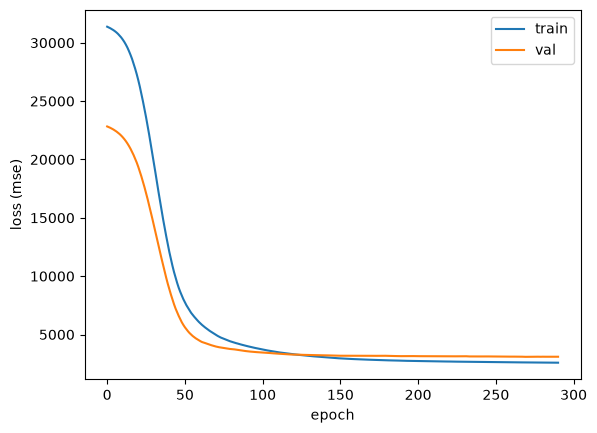

In [43]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch'); plt.ylabel('loss (mse)')
plt.legend(); plt.show()


In [44]:
print("멈춘 epoch:", len(history.history['loss']))
print("최적 epoch:", len(history.history['loss']) - 20)   # patience만큼 뺌


멈춘 epoch: 291
최적 epoch: 271


## 결론: sklearn vs Keras on diabetes

| 모델 | R² | RMSE |
|---|---|---|
| lasso (sklearn) | 0.482 | 54.70 |
| Keras + EarlyStopping | 0.443 | 55.51 |
| Keras (과적합) | 0.250 | 64.40 |

- EarlyStopping으로 과적합을 잡자 R²가 0.25 → 0.44로 개선
- 그래도 선형 모델(lasso)이 근소하게 우위
- **교훈**: 작고 선형적인 데이터는 신경망보다 선형 모델이 유리.
  신경망 사용 시 과적합 관리(EarlyStopping)가 필수.
